In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.show()
import seaborn as sns
import numpy as np
import plotly.graph_objs as go
from plotly.offline import iplot
sns.set()
import datetime as dt
pd.options.display.max_columns = 999

In [2]:
data = pd.read_csv('Adidas US Sales.csv')

In [3]:
data.shape

(9637, 13)

In [4]:
data.head()

,sales_id,retailer,retailer_id,invoice_date,region,state,city,product,price_per_unit,units_sold,total_sales,operating_profit,sales_method
0,1,Foot Locker,1185732,2021-11-06,Southeast,South Carolina,Charleston,Men's Street Footwear,50,278,13900,792,Online
1,2,Foot Locker,1185732,2020-03-14,Northeast,New York,New York,Men's Apparel,46,278,12788,435,Outlet
2,3,West Gear,1128299,2021-01-19,West,California,San Francisco,Men's Athletic Footwear,47,278,13066,287,Outlet
3,4,Walmart,1128299,2021-06-17,Southeast,Florida,Orlando,Women's Apparel,103,218,22454,1257,Online
4,5,Sports Direct,1197831,2021-09-14,South,Alabama,Birmingham,Women's Street Footwear,36,278,10008,530,Outlet


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9637 entries, 0 to 9636
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sales_id          9637 non-null   int64 
 1   retailer          9637 non-null   object
 2   retailer_id       9637 non-null   int64 
 3   invoice_date      9637 non-null   object
 4   region            9637 non-null   object
 5   state             9637 non-null   object
 6   city              9637 non-null   object
 7   product           9637 non-null   object
 8   price_per_unit    9637 non-null   int64 
 9   units_sold        9637 non-null   int64 
 10  total_sales       9637 non-null   int64 
 11  operating_profit  9637 non-null   int64 
 12  sales_method      9637 non-null   object
dtypes: int64(6), object(7)
memory usage: 978.9+ KB


In [7]:
data.describe()

,sales_id,retailer_id,price_per_unit,units_sold,total_sales,operating_profit
count,9637.000000,9.637000e+03,9637.000000,9637.000000,9637.000000,9637.000000
mean,4819.000000,1.173846e+06,45.218948,256.886064,12451.621355,3440.706029
std,2782.106606,2.636304e+04,14.704520,214.097600,12708.094249,5418.210200
min,1.000000,1.128299e+06,7.000000,6.000000,160.000000,8.000000
25%,2410.000000,1.185732e+06,35.000000,106.000000,4068.000000,192.000000
50%,4819.000000,1.185732e+06,45.000000,176.000000,7805.000000,437.000000
75%,7228.000000,1.185732e+06,55.000000,350.000000,15834.000000,5200.000000
max,9637.000000,1.197831e+06,110.000000,1275.000000,82500.000000,39000.000000


In [8]:
data['invoice_date'] = pd.to_datetime(data['invoice_date'])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9637 entries, 0 to 9636
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_id          9637 non-null   int64         
 1   retailer          9637 non-null   object        
 2   retailer_id       9637 non-null   int64         
 3   invoice_date      9637 non-null   datetime64[ns]
 4   region            9637 non-null   object        
 5   state             9637 non-null   object        
 6   city              9637 non-null   object        
 7   product           9637 non-null   object        
 8   price_per_unit    9637 non-null   int64         
 9   units_sold        9637 non-null   int64         
 10  total_sales       9637 non-null   int64         
 11  operating_profit  9637 non-null   int64         
 12  sales_method      9637 non-null   object        
dtypes: datetime64[ns](1), int64(6), object(6)
memory usage: 978.9+ KB


In [10]:
print(data.isnull().sum())

sales_id            0
retailer            0
retailer_id         0
invoice_date        0
region              0
state               0
city                0
product             0
price_per_unit      0
units_sold          0
total_sales         0
operating_profit    0
sales_method        0
dtype: int64


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.drop(columns=['sales_id', 'retailer_id'], inplace=True)
# Removing this columns because they are not relevant to the analysis

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9637 entries, 0 to 9636
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   retailer          9637 non-null   object        
 1   invoice_date      9637 non-null   datetime64[ns]
 2   region            9637 non-null   object        
 3   state             9637 non-null   object        
 4   city              9637 non-null   object        
 5   product           9637 non-null   object        
 6   price_per_unit    9637 non-null   int64         
 7   units_sold        9637 non-null   int64         
 8   total_sales       9637 non-null   int64         
 9   operating_profit  9637 non-null   int64         
 10  sales_method      9637 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(6)
memory usage: 828.3+ KB


In [14]:
data['retailer'].unique()

array(['Foot Locker', 'West Gear', 'Walmart', 'Sports Direct', 'Amazon',
       "Kohl's"], dtype=object)

In [15]:
# Exploring the invoice_date column
data['invoice_date']

0      2021-11-06
1      2020-03-14
2      2021-01-19
3      2021-06-17
4      2021-09-14
          ...    
9632   2021-11-18
9633   2021-10-22
9634   2021-10-22
9635   2021-04-10
9636   2021-10-05
Name: invoice_date, Length: 9637, dtype: datetime64[ns]

In [23]:
# Decided to extract the Year, Month & Day from invoice_date so its cleaner for analysis
data['year'] = data['invoice_date'].dt.year

In [17]:
data['year']

0       2021
1       2020
2       2021
3       2021
4       2021
        ... 
9632    2021
9633    2021
9634    2021
9635    2021
9636    2021
Name: year, Length: 9637, dtype: int32

In [18]:
data['month'] = data['invoice_date'].dt.month

In [19]:
data['month']

0       11
1        3
2        1
3        6
4        9
        ..
9632    11
9633    10
9634    10
9635     4
9636    10
Name: month, Length: 9637, dtype: int32

In [21]:
# Set month name for cleaner analysis
data['month_name'] = pd.to_datetime(data['month'], format='%m').dt.month_name().str[:3]

In [22]:
data['month_name']

0       Nov
1       Mar
2       Jan
3       Jun
4       Sep
       ... 
9632    Nov
9633    Oct
9634    Oct
9635    Apr
9636    Oct
Name: month_name, Length: 9637, dtype: object

In [24]:
data['day'] = data['invoice_date'].dt.day

In [26]:
def set_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'

data['season'] = data['month'].apply(set_season)
data['season']
    

0       Autumn
1       Spring
2       Winter
3       Summer
4       Autumn
         ...  
9632    Autumn
9633    Autumn
9634    Autumn
9635    Spring
9636    Autumn
Name: season, Length: 9637, dtype: object

In [27]:
# season is set as a category column
data['season'] = data['season'].astype('category')

In [28]:
data.head()

,retailer,invoice_date,region,state,city,product,price_per_unit,units_sold,total_sales,operating_profit,sales_method,year,month,month_name,day,season
0,Foot Locker,2021-11-06,Southeast,South Carolina,Charleston,Men's Street Footwear,50,278,13900,792,Online,2021,11,Nov,6,Autumn
1,Foot Locker,2020-03-14,Northeast,New York,New York,Men's Apparel,46,278,12788,435,Outlet,2020,3,Mar,14,Spring
2,West Gear,2021-01-19,West,California,San Francisco,Men's Athletic Footwear,47,278,13066,287,Outlet,2021,1,Jan,19,Winter
3,Walmart,2021-06-17,Southeast,Florida,Orlando,Women's Apparel,103,218,22454,1257,Online,2021,6,Jun,17,Summer
4,Sports Direct,2021-09-14,South,Alabama,Birmingham,Women's Street Footwear,36,278,10008,530,Outlet,2021,9,Sep,14,Autumn


In [29]:
data.shape

(9637, 16)

In [32]:
data['total_sales'].nunique()

3081

In [34]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

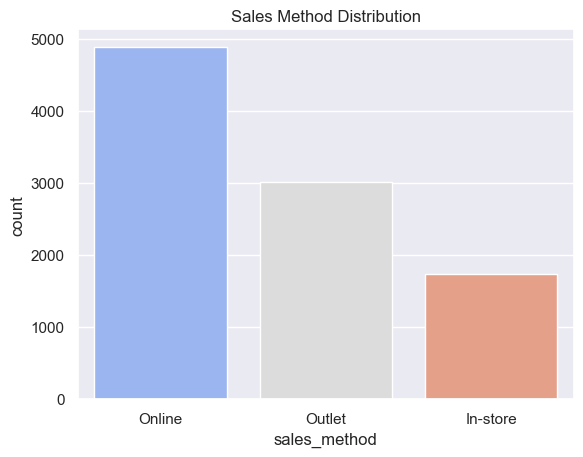

In [35]:
# checking the distribution of sales method
sns.countplot(data=data, x='sales_method', order=data['sales_method'].value_counts().index, palette='coolwarm').set_title('Sales Method Distribution')
plt.show()

### Performance Breakdown of KPIs

#### 1. Total Sales, Operating Profit & Units Sold by Retailer

In [37]:
retailer_sales = data.groupby('retailer').sum('total_sales').sort_values('total_sales', ascending=False)
retailer_sales['total_sales_pct'] = ((retailer_sales['total_sales'] / retailer_sales['total_sales'].sum()) * 100).round(2)
retailer_sales['op_profit_pct'] = ((retailer_sales['operating_profit'] / retailer_sales['operating_profit'].sum()) * 100).round(2)
retailer_sales['units_sold_pct'] = ((retailer_sales['units_sold'] / retailer_sales['units_sold'].sum()) * 100).round(2)
retailer_sales[['total_sales', 'operating_profit', 'units_sold', 'total_sales_pct', 'op_profit_pct', 'units_sold_pct']]

,total_sales,operating_profit,units_sold,total_sales_pct,op_profit_pct,units_sold_pct
retailer,,,,,,
West Gear,32317808,8538806,624012,26.93,25.75,25.21
Foot Locker,29004945,8065150,603919,24.17,24.32,24.39
Sports Direct,24557997,7412864,556090,20.47,22.36,22.46
Kohl's,13512453,3681153,287375,11.26,11.10,11.61
Walmart,10506085,2578226,206225,8.76,7.78,8.33
Amazon,10096987,2881885,197990,8.41,8.69,8.00


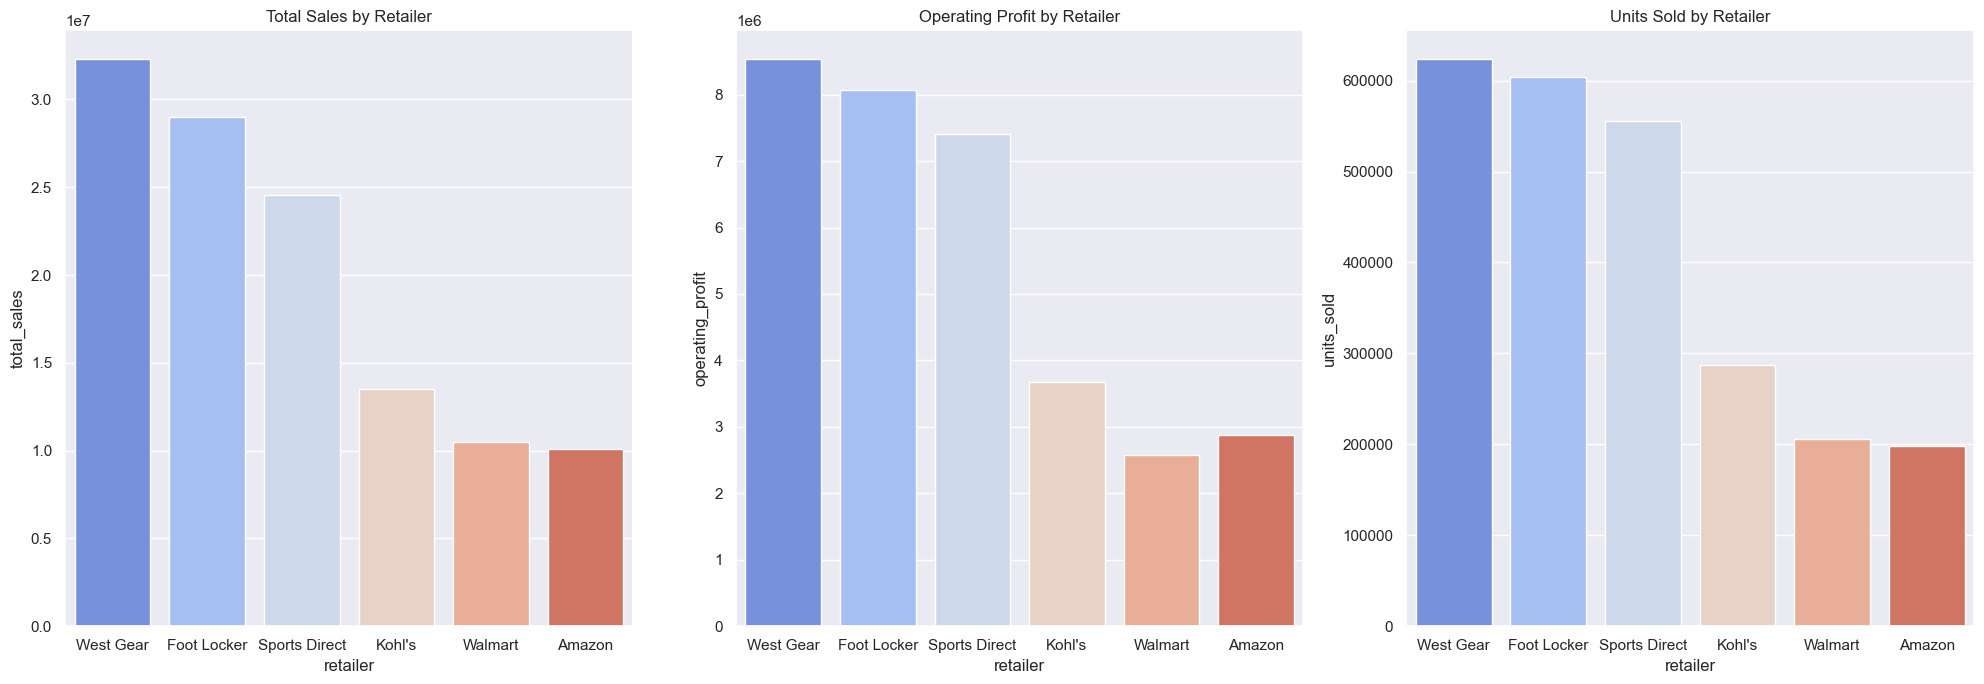

In [38]:
plt.figure(figsize=(20, 7))

plt.subplot(1,3,1)
bp1 = sns.barplot(data=retailer_sales, x=retailer_sales.index, y='total_sales', palette='coolwarm')
bp1.set_title('Total Sales by Retailer')

plt.subplot(1,3,2)
bp2 = sns.barplot(data=retailer_sales, x=retailer_sales.index, y='operating_profit', palette='coolwarm')
bp2.set_title('Operating Profit by Retailer')

plt.subplot(1,3,3)
bp3 = sns.barplot(data=retailer_sales, x=retailer_sales.index, y='units_sold', palette='coolwarm')
bp3.set_title('Units Sold by Retailer')

plt.tight_layout()
plt.show()

#### Insight: West Gear, Foot Locker, and Sports Direct stand out as the leading retailers, jointly contributing 72% of total sales, operating profit, and units sold.

#### 2. Total Sales, Operating Profit & Units Sold by Region

In [41]:
region_sales = data.groupby('region').sum('total_sales').sort_values('total_sales', ascending=False)
region_sales['total_sales_pct'] = ((region_sales['total_sales'] / region_sales['total_sales'].sum()) * 100).round(2)
region_sales['op_profit_pct'] = ((region_sales['operating_profit'] / region_sales['operating_profit'].sum()) * 100).round(2)
region_sales['units_sold_pct'] = ((region_sales['units_sold'] / region_sales['units_sold'].sum()) * 100).round(2)
region_sales[['total_sales', 'operating_profit', 'units_sold', 'total_sales_pct', 'op_profit_pct', 'units_sold_pct']]

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,total_sales,operating_profit,units_sold,total_sales_pct,op_profit_pct,units_sold_pct
region,,,,,,
West,36344407,8932969,685735,30.29,26.94,27.70
Northeast,25078267,6802150,501279,20.90,20.51,20.25
Southeast,21374436,6055601,407000,17.81,18.26,16.44
South,20544731,6093344,490710,17.12,18.38,19.82
Midwest,16654434,5274020,390887,13.88,15.91,15.79


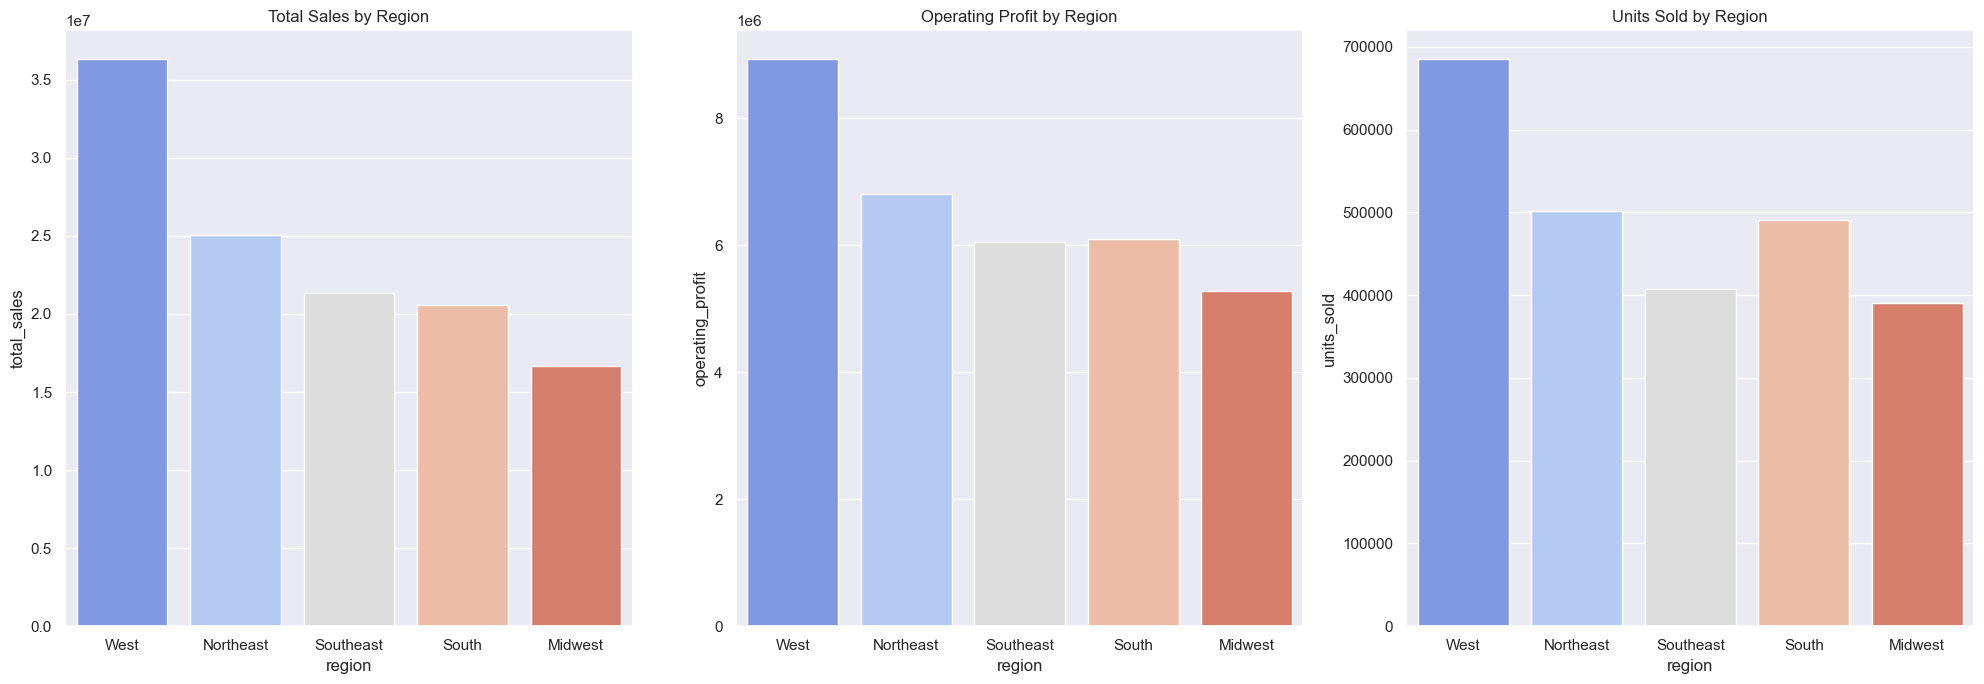

In [42]:
plt.figure(figsize=(20, 7))

plt.subplot(1,3,1)
bp1 = sns.barplot(data=region_sales, x=region_sales.index, y='total_sales', palette='coolwarm')
bp1.set_title('Total Sales by Region')

plt.subplot(1,3,2)
bp2 = sns.barplot(data=region_sales, x=region_sales.index, y='operating_profit', palette='coolwarm')
bp2.set_title('Operating Profit by Region')

plt.subplot(1,3,3)
bp3 = sns.barplot(data=region_sales, x=region_sales.index, y='units_sold', palette='coolwarm')
bp3.set_title('Units Sold by Region')

plt.tight_layout()
plt.show()

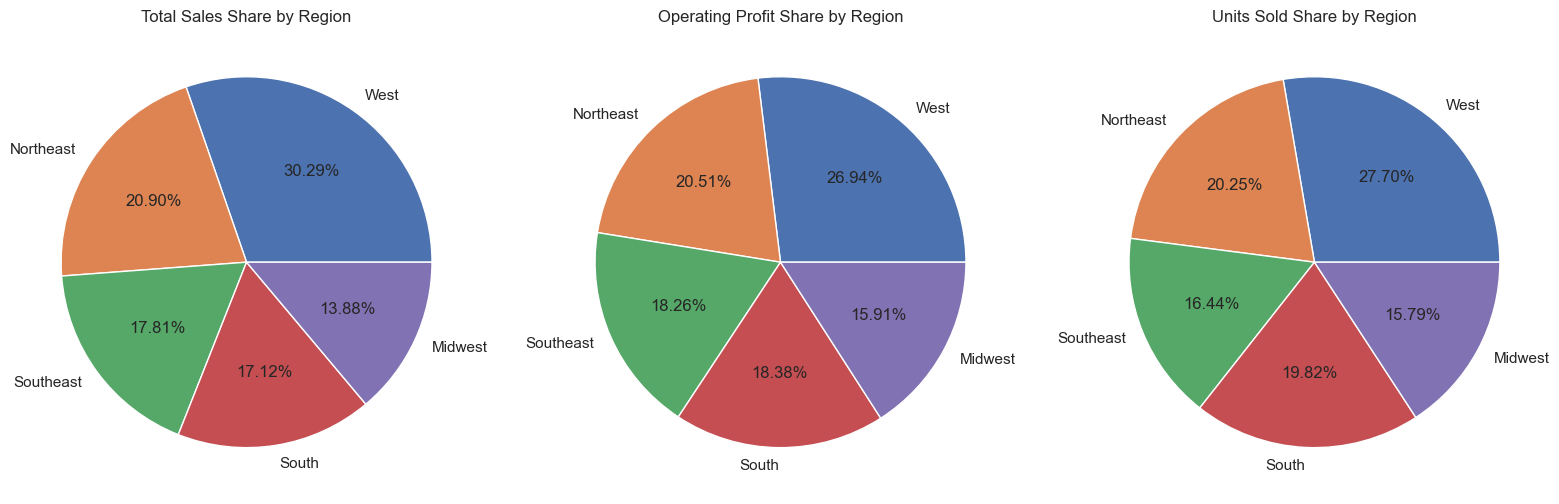

In [43]:
plt.figure(figsize=(16, 7))

plt.subplot(1,3,1)
plt.pie(data=region_sales, x='total_sales_pct', labels=region_sales.index, autopct='%.2f%%')
plt.title('Total Sales Share by Region')

plt.subplot(1,3,2)
plt.pie(data=region_sales, x='op_profit_pct', labels=region_sales.index, autopct='%.2f%%')
plt.title('Operating Profit Share by Region')

plt.subplot(1,3,3)
plt.pie(data=region_sales, x='units_sold_pct', labels=region_sales.index, autopct='%.2f%%')
plt.title('Units Sold Share by Region')

plt.tight_layout()
plt.show()

#### Insight: The West and Northeast regions stand out as the top performers, together contributing 51% of total sales, 47% of operating profit, and 48% of units sold.

#### 3. Total Sales, Operating Profit & Units Sold by Product

In [44]:
product_sales = data.groupby('product').sum('total_sales').sort_values('total_sales', ascending=False)
product_sales['total_sales_pct'] = ((product_sales['total_sales'] / product_sales['total_sales'].sum()) * 100).round(2)
product_sales['op_profit_pct'] = ((product_sales['operating_profit'] / product_sales['operating_profit'].sum()) * 100).round(2)
product_sales['units_sold_pct'] = ((product_sales['units_sold'] / product_sales['units_sold'].sum()) * 100).round(2)
product_sales[['total_sales', 'operating_profit', 'units_sold', 'total_sales_pct', 'op_profit_pct', 'units_sold_pct']]

,total_sales,operating_profit,units_sold,total_sales_pct,op_profit_pct,units_sold_pct
product,,,,,,
Men's Street Footwear,27680769,8280294,593320,23.07,24.97,23.97
Women's Apparel,23814985,6856750,433127,19.85,20.68,17.50
Men's Athletic Footwear,20532180,5168997,434451,17.11,15.59,17.55
Women's Street Footwear,17171938,4499284,391444,14.31,13.57,15.81
Men's Apparel,16484882,4456719,306133,13.74,13.44,12.37
Women's Athletic Footwear,14311521,3896040,317136,11.93,11.75,12.81


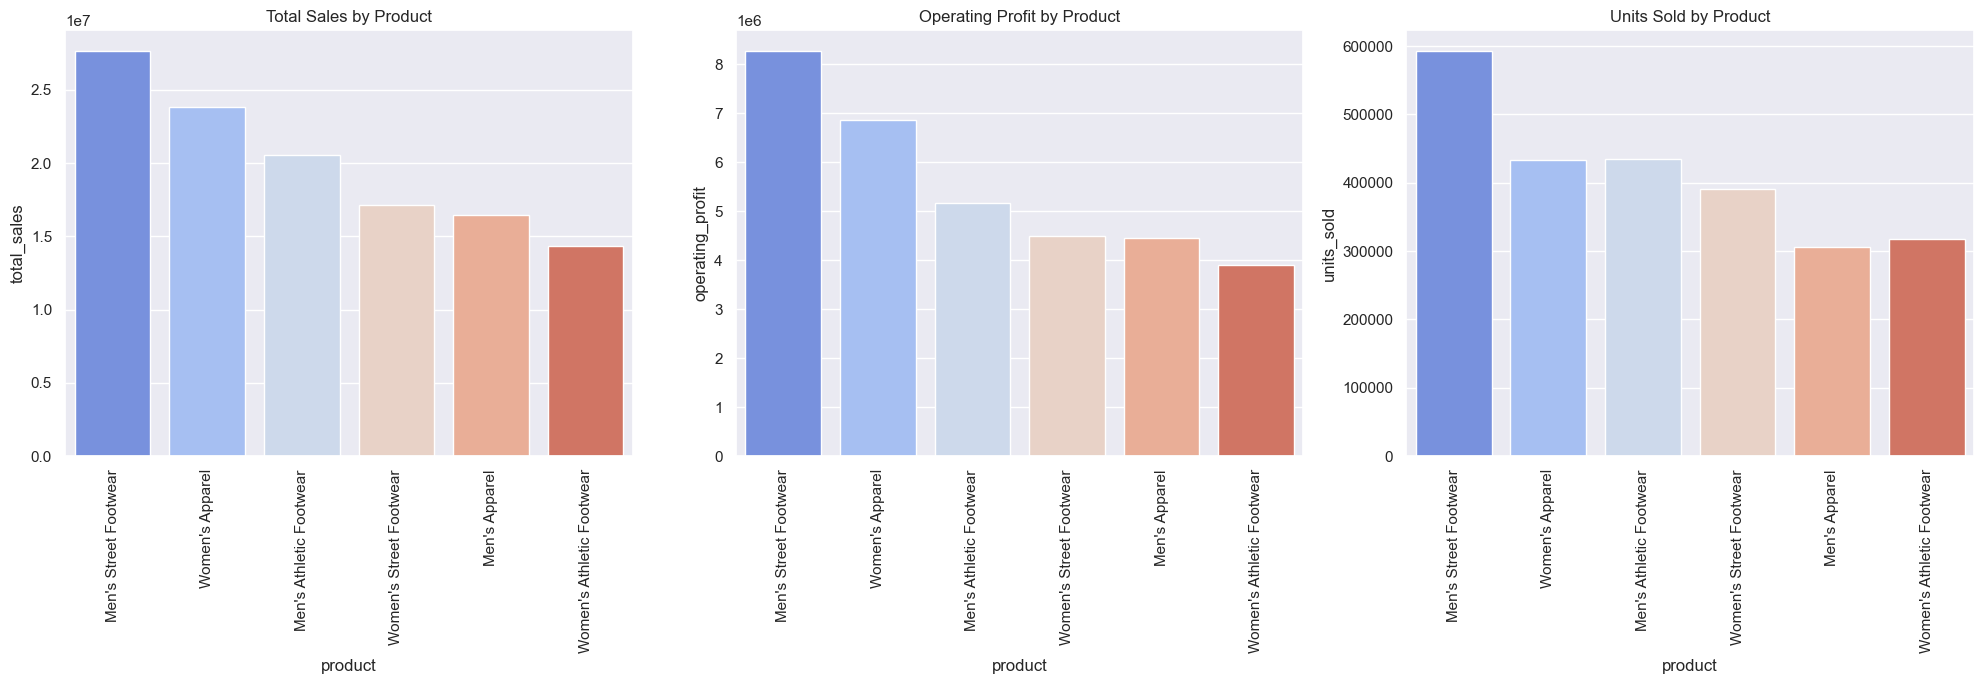

In [45]:
plt.figure(figsize=(20, 7))

plt.subplot(1,3,1)
bp1 = sns.barplot(data=product_sales, x=product_sales.index, y='total_sales', palette='coolwarm')
bp1.set_title('Total Sales by Product')
plt.xticks(rotation=90)

plt.subplot(1,3,2)
bp2 = sns.barplot(data=product_sales, x=product_sales.index, y='operating_profit', palette='coolwarm')
bp2.set_title('Operating Profit by Product')
plt.xticks(rotation=90)

plt.subplot(1,3,3)
bp3 = sns.barplot(data=product_sales, x=product_sales.index, y='units_sold', palette='coolwarm')
bp3.set_title('Units Sold by Product')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#### Insight: Men’s Street Footwear, Women’s Apparel, and Men’s Athletic Footwear stand out as the leading product categories, collectively contributing 60% of total sales, 61% of operating profit, and 59% of units sold.

#### 4. Total Sales, Operating Profit & Units Sold by Season

In [47]:
season_sales = data.groupby('season').sum('total_sales').sort_values('total_sales', ascending=False)
season_sales['total_sales_pct'] = ((season_sales['total_sales'] / season_sales['total_sales'].sum()) * 100).round(2)
season_sales['op_profit_pct'] = ((season_sales['operating_profit'] / season_sales['operating_profit'].sum()) * 100).round(2)
season_sales['units_sold_pct'] = ((season_sales['units_sold'] / season_sales['units_sold'].sum()) * 100).round(2)
season_sales[['total_sales', 'operating_profit', 'units_sold', 'total_sales_pct', 'op_profit_pct', 'units_sold_pct']]

,total_sales,operating_profit,units_sold,total_sales_pct,op_profit_pct,units_sold_pct
season,,,,,,
Summer,34568167,9494494,655435,28.81,28.63,26.48
Winter,29332202,7784501,612132,24.44,23.48,24.73
Spring,28128124,7794619,621991,23.44,23.51,25.12
Autumn,27967782,8084470,586053,23.31,24.38,23.67


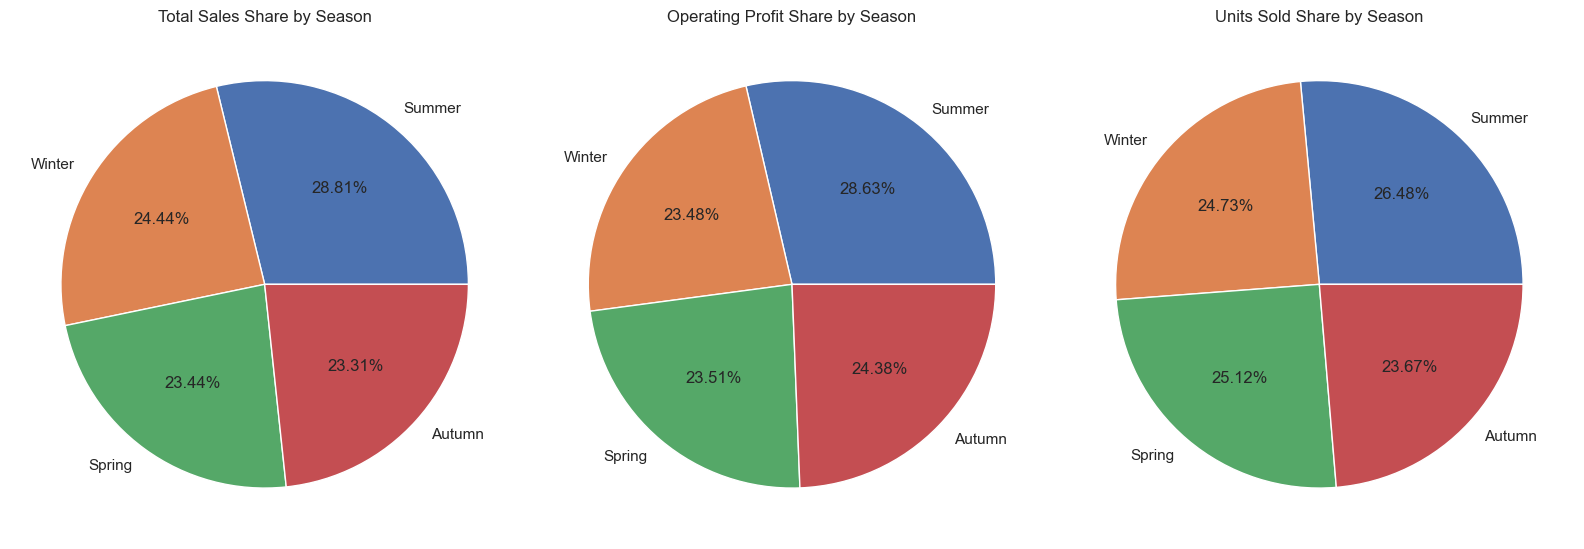

In [48]:
plt.figure(figsize=(16, 7))

plt.subplot(1,3,1)
plt.pie(data=season_sales, x='total_sales_pct', labels=season_sales.index, autopct='%.2f%%')
plt.title('Total Sales Share by Season')

plt.subplot(1,3,2)
plt.pie(data=season_sales, x='op_profit_pct', labels=season_sales.index, autopct='%.2f%%')
plt.title('Operating Profit Share by Season')

plt.subplot(1,3,3)
plt.pie(data=season_sales, x='units_sold_pct', labels=season_sales.index, autopct='%.2f%%')
plt.title('Units Sold Share by Season')

plt.tight_layout()
plt.show()

#### Insight: Summer stands out as the top-performing season, accounting for 29% of total sales, 29% of operating profit, and 26% of units sold. This seasonal surge is likely driven by increased shopping during the summer break.

In [49]:
data.to_excel("adidas_sales_cleaned.xlsx", index=False)

In [51]:
data.head()

,retailer,invoice_date,region,state,city,product,price_per_unit,units_sold,total_sales,operating_profit,sales_method,year,month,month_name,day,season
0,Foot Locker,2021-11-06,Southeast,South Carolina,Charleston,Men's Street Footwear,50,278,13900,792,Online,2021,11,Nov,6,Autumn
1,Foot Locker,2020-03-14,Northeast,New York,New York,Men's Apparel,46,278,12788,435,Outlet,2020,3,Mar,14,Spring
2,West Gear,2021-01-19,West,California,San Francisco,Men's Athletic Footwear,47,278,13066,287,Outlet,2021,1,Jan,19,Winter
3,Walmart,2021-06-17,Southeast,Florida,Orlando,Women's Apparel,103,218,22454,1257,Online,2021,6,Jun,17,Summer
4,Sports Direct,2021-09-14,South,Alabama,Birmingham,Women's Street Footwear,36,278,10008,530,Outlet,2021,9,Sep,14,Autumn
